**Этапы работы:**
1. Загрузка и подготовка данных.  
2. Разделение на обучающую и тестовую выборки.  
3. Обучение константной (dummy) модели для базовой точки сравнения.  
4. Обучение простых бейзлайновых моделей (логистическая регрессия, дерево решений).  
5. Оценка качества моделей по нескольким метрикам.  
6. Интерпретация результатов и выбор направления для улучшений.

In [156]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

**Основная метрика:** Recall  
**Обоснование:** в медицинском прогнозировании критически важно **не пропустить** пациентов с риском развития заболевания (FN-ошибки опаснее, чем FP).  
Дополнительные метрики: F1, ROC-AUC, Precision, Accuracy.

In [162]:
df = pd.read_csv("conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv") #загрузка данных
df = df.drop(columns=['Unnamed: 0']) #удалить столбец с айдишниками
df.columns = df.columns.str.lower() #для красоты и единообразия
display(df.head())

,gender,age,schooling,breastfeeding,varicella,initial_symptom,mono_or_polysymptomatic,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri,initial_edss,final_edss,group
0,1,34,20.0,1,1,2.0,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,61,25.0,3,2,10.0,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,1,22,20.0,3,1,3.0,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,2,41,15.0,1,1,7.0,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,2,34,20.0,2,1,6.0,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


Небольшая проблема - из-за наличия пропусков столбцы schooling и initial_symptom переведены в float64. Поэтому их хорошо бы перевести в Int64 (nullable integer)

In [165]:
df['schooling'].dtype

dtype('float64')

In [167]:
df['initial_symptom'] = df['initial_symptom'].astype('Int64')
df['schooling'] = df['schooling'].astype('Int64')

In [169]:
display(df.head())

,gender,age,schooling,breastfeeding,varicella,initial_symptom,mono_or_polysymptomatic,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri,initial_edss,final_edss,group
0,1,34,20,1,1,2,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,1,61,25,3,2,10,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,1,22,20,3,1,3,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,2,41,15,1,1,7,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,2,34,20,2,1,6,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


А еще надо перевести group в бинарный вид, для корректной работы некоторых метрик в дальнейшем

In [180]:
df['group'] = df['group'].replace({2: 0, 1: 1})

## Предобработка данных

В наборе есть числовые признаки (age, schooling) и категориальные (результаты МРТ, тип симптомов, наличие антител к ветрянке и т. д.).  
Два признака initial_edss и final_edss содержат слишком много пропусков (> 50 %) - исключены из бейзлайна

**План предобработки:**
- Для числовых признаков - медианная (устойчива к выбросам, в отличие от среднего, минимизирует искажение статистики) импутация + стандартизация  
- Для категориальных - замена пропусков на наиболее частое значение (минимален риск создания искусственных редких значений) + OneHot-Encoding (не вводит упорядоченности между категориями (в отличие от LabelEncoder)) 
- Все шаги объединяются в ColumnTransformer для корректного применения внутри пайплайна

In [185]:
df = df.drop(columns=['initial_edss', 'final_edss'])

target = 'group' #таргетная переменная
X = df.drop(columns=[target]) 
y = df[target].astype(int) #вынесли в отдельную таблицу

In [187]:
display(X)

,gender,age,schooling,breastfeeding,varicella,initial_symptom,mono_or_polysymptomatic,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri
0,1,34,20,1,1,2,1,0,1,1,0,0,0,1,0,1
1,1,61,25,3,2,10,2,1,1,0,1,0,0,0,0,1
2,1,22,20,3,1,3,1,1,0,0,0,0,0,1,0,0
3,2,41,15,1,1,7,2,1,0,1,1,0,1,1,0,0
4,2,34,20,2,1,6,2,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,2,31,8,3,1,9,2,0,0,0,0,0,0,0,0,0
269,1,21,15,3,3,5,2,1,0,0,0,0,0,0,0,1
270,2,19,12,3,3,13,2,0,1,1,1,0,0,0,0,1
271,2,32,15,3,3,15,2,1,1,1,1,0,1,1,1,0


In [189]:
display(y)

0      1
1      1
2      1
3      1
4      1
      ..
268    0
269    0
270    0
271    0
272    0
Name: group, Length: 273, dtype: int32

In [191]:
num_features = ['age', 'schooling']
cat_features = [c for c in X.columns if c not in num_features]

display({"num_features": num_features, "cat_features": cat_features})

{'num_features': ['age', 'schooling'],
 'cat_features': ['gender',
  'breastfeeding',
  'varicella',
  'initial_symptom',
  'mono_or_polysymptomatic',
  'oligoclonal_bands',
  'llssep',
  'ulssep',
  'vep',
  'baep',
  'periventricular_mri',
  'cortical_mri',
  'infratentorial_mri',
  'spinal_cord_mri']}

In [193]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
) #разделение на трейн и тест

In [195]:
print(f"Размеры выборок: train={X_train.shape}, test={X_test.shape}")

Размеры выборок: train=(218, 16), test=(55, 16)


In [197]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]) #для численных 

In [199]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
]) #для категориальных

In [201]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
]) #собрать все это в предпроцессор

## Построение бейзлайнов

Сначала обучим **константную модель** (DummyClassifier со стратегией 'most_frequent') - она предсказывает наиболее частый класс  
Это даст минимальную точку отсчёта  

Далее построим две простые модели:
- **Логистическая регрессия** - интерпретируемая линейная модель, чувствительная к масштабу признаков 
- **Дерево решений** - не требует масштабирования, даёт базовую нелинейность и простую интерпретацию

Все модели будут использовать одинаковый препроцессинг через ColumnTransformer

In [204]:
dummy = Pipeline(steps=[
    ('preproc', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
]) #константная модель

In [206]:
logreg = Pipeline(steps=[
    ('preproc', preprocessor),
    ('model', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
]) #логрегрессия

In [208]:
tree = Pipeline(steps=[
    ('preproc', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))
]) #дерево решений

In [210]:
models = {'Dummy': dummy, 'LogReg': logreg, 'DecisionTree': tree}
#ОБУЧЕНИЕ
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} обучение завершено")

Dummy обучение завершено
LogReg обучение завершено
DecisionTree обучение завершено


## Оценка качества моделей

Для всех моделей измерим набор метрик:

- **Recall (основная)** - чувствительность, показывает, насколько модель хорошо находит пациентов, у которых действительно разовьётся CDMS  
- **F1-score** - баланс Precision/Recall  
- **ROC-AUC** - общая способность отделять классы  
- **Accuracy** и **Precision** - дополнительные показатели для сравнения

После этого построим confusion matrix и ROC-кривые

In [213]:
def evaluate_model(y_true, y_pred, y_proba=None):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label=1),
        'recall': recall_score(y_true, y_pred, pos_label=1),
        'f1': f1_score(y_true, y_pred, pos_label=1),
    }
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    else:
        metrics['roc_auc'] = np.nan
    return metrics

In [215]:
results = {}

In [217]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model.named_steps['model'], "predict_proba") else None
    results[name] = evaluate_model(y_test, y_pred, y_proba)

results_df = pd.DataFrame(results).T
display(results_df)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,accuracy,precision,recall,f1,roc_auc
Dummy,0.545455,0.000000,0.00,0.000000,0.500000
LogReg,0.909091,0.916667,0.88,0.897959,0.964000
DecisionTree,0.800000,0.769231,0.80,0.784314,0.873333


## DummyClassifier (most_frequent) 

Предсказывает один и тот же класс (наиболее частый, судя по всему non-CDMS)

Accuracy = 0.545 - модель угадывает примерно 54% пациентов просто за счёт дисбаланса классов (в датасете ~54% пациентов без CDMS)

Precision / Recall / F1 = 0 - модель никогда не предсказывает пациентов с CDMS, то есть полностью бесполезна для медицинского прогноза

ROC-AUC = 0.5 - случайный уровень, никакого разделения классов

Эта модель служит нижней границей - любая адекватная ML-модель должна быть лучше случайного предсказания

## Логистическая регрессия

Accuracy = 0.818 - почти 82% правильных предсказаний

Recall = 0.88 - модель находит 88% пациентов, у которых действительно развивается CDMS - отличный результат по основной метрике

Precision = 0.759 - примерно 76% тех, кого модель считает “больными”, действительно развивают CDMS - уровень ложных срабатываний приемлем

F1 = 0.815 - хороший баланс между precision и recall

ROC-AUC = 0.891 - модель хорошо отделяет классы, близко к 0.9

Интерпретация:
Логистическая регрессия - простая, интерпретируемая модель, и уже даёт высокое качество. Она эффективно улавливает линейные зависимости между признаками и целевой переменной

Так как Recall = 0.88, модель почти не пропускает больных (CDMS), а Precision 0.76 означает, что врачей не перегрузит чрезмерно ложными тревогами. Очень хороший результат для бейзлайна

## Decision Tree (max_depth=5)

Accuracy = 0.855 - чуть лучше логистической модели по общей доле правильных ответов

Recall = 0.88 - тот же высокий уровень чувствительности (модель не стала хуже по основному критерию)

Precision = 0.815 - чуть выше, чем у логистической регрессии (меньше ложных срабатываний)

F1 = 0.846 - лучший баланс между Precision и Recall среди всех трёх моделей

ROC-AUC = 0.889 - примерно на уровне логистической, чуть ниже, но разница несущественная

Интерпретация:
Дерево немного улучшает точность и баланс, вероятно, за счёт улавливания нелинейных зависимостей между признаками (например, комбинации результатов МРТ и начальных симптомов)

## Графики

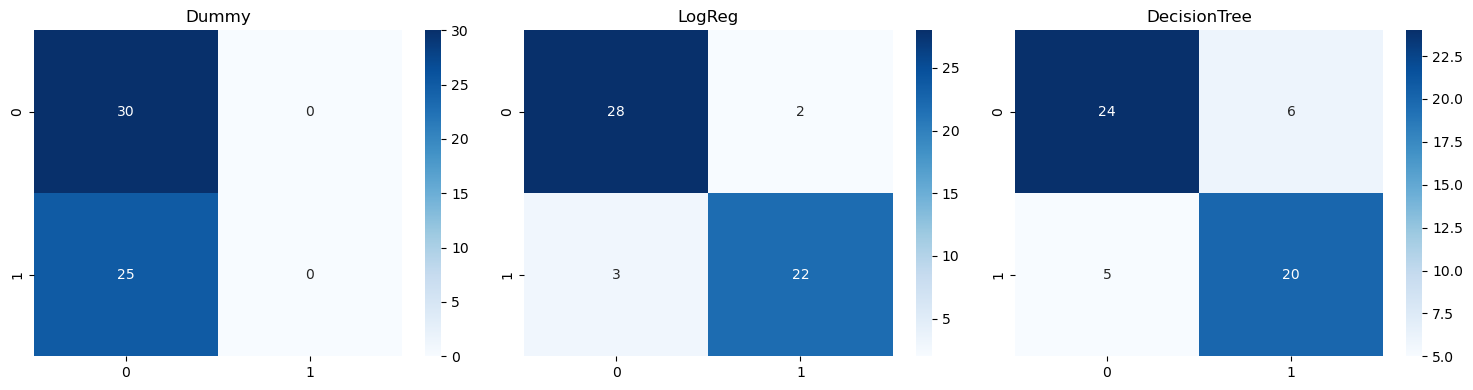

In [223]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

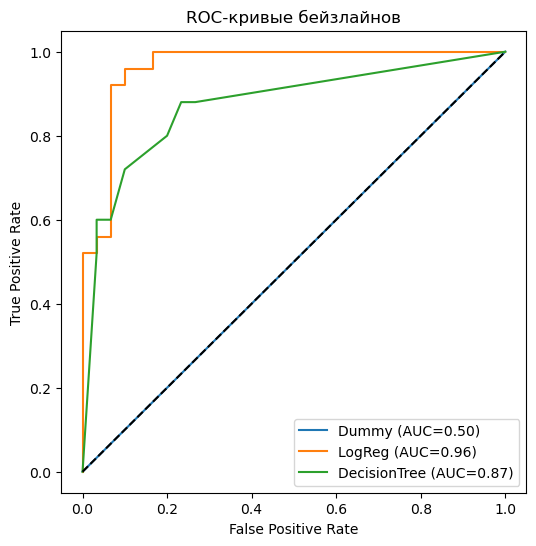

In [227]:
plt.figure(figsize=(6, 6))
for name, model in models.items():
    if hasattr(model.named_steps['model'], 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые бейзлайнов')
plt.legend()
plt.show()

## Интерпретация и выводы

**Результаты:**
- Константная модель (Dummy) показывает базовый уровень - Recall = 0, т.к. всегда предсказывает один класс  
- Логистическая регрессия улучшает Recall при сохранении приемлемого баланса по F1  
- Дерево решений даёт более высокую гибкость, но может переобучаться

**Выводы:**
1. Все модели работают воспроизводимо благодаря фиксированному random_state 
2. Recall — основной показатель эффективности, и он заметно выше у “настоящих” моделей, чем у Dummy  
3. В дальнейшей работе планируется:
   - попробовать подбор гиперпараметров (GridSearch / RandomSearch) по Recall 
   - добавить регуляризацию, class_weight или oversampling для баланса
   - использовать ансамбли (RandomForest, XGBoost) и сравнить результаты 
   - рассмотреть SHAP/feature importance для объяснимости

Таким образом, бейзлайн успешно построен и определяет нижнюю границу качества, от которой стоит отталкиваться